In [6]:
pwd

'C:\\Users\\User\\Desktop\\My-Python-Project\\Python-World-Bank-Data-Analysis'

# IMPORT RELEVANT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
from scipy import stats

In [18]:
%pip install scipy

   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/36.6 MB ? eta -:--:--
    --------------------------------------- 0.5/36.6 MB 1.0 MB/s eta 0:00:35
   - -------------------------------------- 1.0/36.6 MB 1.6 MB/s eta 0:00:22
   -- ------------------------------------- 2.1/36.6 MB 2.5 MB/s eta 0:00:14
   -- ------------------------------------- 2.1/36.6 MB 2.5 MB/s eta 0:00:14
   ---- ----------------------------------- 4.2/36.6 MB 3.8 MB/s eta 0:00:09
   ----- ---------------------------------- 4.7/36.6 MB 3.3 MB/s eta 0:00:10
   ----- ---------------------------------- 5.0/36.6 MB 3.5 MB/s eta 0:00:10
   ------- -------------------------------- 7.1/36.6 MB 4.0 MB/s eta 0:00:08
   -------- ------------------------------- 8.1/36.6 MB 4.0 MB/s eta 0:00:08
   --------- --------------

# 1. DATA PREPERATION

# LOADING THE EDUCATION STATISTICS DATASET INTO A DATAFRAME

In [12]:
edu_data = pd.read_csv('data/WB_EDSTATS_WIDEF.csv', sep=';', low_memory = False)

# LOADING THE WORLD DEVELOPMENT INDICATORS DATASET INTO A DATAFRAME

In [14]:
wdi_data = pd.read_csv('data/WB_WDI_WIDEF.csv', sep=';', low_memory = False)

# VOLUME AND VARIETY OF THE EDUCATION STATISTICS DATASET

In [29]:
edu_data_melted.info()

<class 'pandas.DataFrame'>
RangeIndex: 1627002 entries, 0 to 1627001
Data columns (total 28 columns):
 #   Column                  Non-Null Count    Dtype 
---  ------                  --------------    ----- 
 0   FREQ                    1627002 non-null  str   
 1   FREQ_LABEL              1627002 non-null  str   
 2   REF_AREA                1627002 non-null  str   
 3   REF_AREA_LABEL          1627002 non-null  str   
 4   INDICATOR               1627002 non-null  str   
 5   INDICATOR_LABEL         1627002 non-null  str   
 6   SEX                     1627002 non-null  str   
 7   SEX_LABEL               1627002 non-null  str   
 8   AGE                     1627002 non-null  str   
 9   AGE_LABEL               1627002 non-null  str   
 10  URBANISATION            1627002 non-null  str   
 11  URBANISATION_LABEL      1627002 non-null  str   
 12  UNIT_MEASURE            1627002 non-null  str   
 13  UNIT_MEASURE_LABEL      1627002 non-null  str   
 14  COMP_BREAKDOWN_1        16270

# VOLUME AND VARIETY FOR WORLD DEVELOPMENT INDICATORS DATASET

In [30]:
wdi_data_melted.info()

<class 'pandas.DataFrame'>
RangeIndex: 19272858 entries, 0 to 19272857
Data columns (total 41 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   STRUCTURE               str    
 1   STRUCTURE_ID            str    
 2   ACTION                  str    
 3   FREQ                    str    
 4   REF_AREA                str    
 5   INDICATOR               str    
 6   SEX                     str    
 7   AGE                     str    
 8   URBANISATION            str    
 9   UNIT_MEASURE            str    
 10  COMP_BREAKDOWN_1        str    
 11  COMP_BREAKDOWN_2        str    
 12  COMP_BREAKDOWN_3        str    
 13  AGG_METHOD              str    
 14  UNIT_TYPE               str    
 15  DECIMALS                int64  
 16  DATABASE_ID             str    
 17  TIME_FORMAT             str    
 18  UNIT_MULT               int64  
 19  OBS_STATUS              str    
 20  OBS_CONF                str    
 21  FREQ_LABEL              str    
 22  REF

# DESCRIPTIVE STATISTICS FOR THE EDUCATION STATISTICS DATASET

In [31]:
edu_data_melted.describe()

,UNIT_MULT,Year
count,1627002.0,1.627002e+06
mean,0.0,1.995000e+03
std,0.0,1.471961e+01
min,0.0,1.970000e+03
25%,0.0,1.982000e+03
50%,0.0,1.995000e+03
75%,0.0,2.008000e+03
max,0.0,2.020000e+03


# DESCRIPTIVE STATISTICS FOR THE WORLD DEVELOPMENT INDICATORS DATASET

In [32]:
wdi_data_melted.describe()

,DECIMALS,UNIT_MULT,Year,Value
count,19272858.0,1.927286e+07,1.927286e+07,9.011411e+06
mean,2.0,3.675864e-02,1.992500e+03,4.322633e+15
std,0.0,5.112369e-01,1.905037e+01,8.955548e+18
min,2.0,0.000000e+00,1.960000e+03,-4.178515e+17
25%,2.0,0.000000e+00,1.976000e+03,4.981024e+00
50%,2.0,0.000000e+00,1.992500e+03,3.949151e+01
75%,2.0,0.000000e+00,2.009000e+03,4.787250e+04
max,2.0,9.000000e+00,2.025000e+03,2.435800e+22


# UNPIVOTING THE YEAR COLUMNS FROM THE EDUCATION STATISTICS DATASET

In [19]:
id_vars = [
    'FREQ', 'FREQ_LABEL', 'REF_AREA', 'REF_AREA_LABEL', 
    'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL', 
    'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL', 
    'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1', 
    'COMP_BREAKDOWN_1_LABEL', 'AGG_METHOD', 'AGG_METHOD_LABEL', 
    'DATABASE_ID', 'DATABASE_ID_LABEL', 'UNIT_MULT', 
    'UNIT_MULT_LABEL', 'OBS_STATUS', 'OBS_STATUS_LABEL', 
    'OBS_CONF', 'OBS_CONF_LABEL'
]

edu_data_melted = pd.melt(
    edu_data,
    id_vars= id_vars,
    var_name='Year',
    value_name='Value'
)

# CONVERT THE YEAR COLUMN FROM STRING TO NUMERIC INTEGER TYPE

In [25]:
edu_data_melted['Year'] = pd.to_numeric(edu_data_melted['Year'])

# UNPIVOTING THE YEAR COLUMNS FROM THE WORLD DEVELOPMENT STATISTICS DATASET

In [24]:
id_vars = [
    'STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 
     'INDICATOR', 'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE', 
     'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3', 
     'AGG_METHOD', 'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT', 
     'UNIT_MULT', 'OBS_STATUS', 'OBS_CONF', 'FREQ_LABEL', 'REF_AREA_LABEL', 
     'INDICATOR_LABEL', 'SEX_LABEL', 'AGE_LABEL', 'URBANISATION_LABEL', 
     'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1_LABEL' ,'COMP_BREAKDOWN_2_LABEL', 
     'COMP_BREAKDOWN_3_LABEL', 'AGG_METHOD_LABEL' ,'UNIT_TYPE_LABEL', 
     'DECIMALS_LABEL', 'DATABASE_ID_LABEL', 'TIME_FORMAT_LABEL', 'UNIT_MULT_LABEL', 
     'OBS_STATUS_LABEL', 'OBS_CONF_LABEL'
]

wdi_data_melted = pd.melt(
    wdi_data,
    id_vars= id_vars,
    var_name='Year',
    value_name='Value'
)

# CONVERT THE YEAR COLUMN FROM STRING TO NUMERIC INTEGER TYPE

In [26]:
wdi_data_melted['Year'] = pd.to_numeric(wdi_data_melted['Year'])

# IDENTIFYING MISSING VALUES FROM EDUCATION STATISTICS DATASET

In [33]:
print(edu_data_melted.isna().sum())

FREQ                            0
FREQ_LABEL                      0
REF_AREA                        0
REF_AREA_LABEL                  0
INDICATOR                       0
INDICATOR_LABEL                 0
SEX                             0
SEX_LABEL                       0
AGE                             0
AGE_LABEL                       0
URBANISATION                    0
URBANISATION_LABEL              0
UNIT_MEASURE                    0
UNIT_MEASURE_LABEL              0
COMP_BREAKDOWN_1                0
COMP_BREAKDOWN_1_LABEL          0
AGG_METHOD                      0
AGG_METHOD_LABEL                0
DATABASE_ID                     0
DATABASE_ID_LABEL               0
UNIT_MULT                       0
UNIT_MULT_LABEL                 0
OBS_STATUS                      0
OBS_STATUS_LABEL                0
OBS_CONF                        0
OBS_CONF_LABEL                  0
Year                            0
Value                     1280637
dtype: int64


# IDENTIFYING MISSING VALUES FROM THE WORLD DEVELOPMENT INDICATORS DATASET

In [34]:
print(wdi_data_melted.isna().sum())

STRUCTURE                        0
STRUCTURE_ID                     0
ACTION                           0
FREQ                             0
REF_AREA                         0
INDICATOR                        0
SEX                              0
AGE                              0
URBANISATION                     0
UNIT_MEASURE                     0
COMP_BREAKDOWN_1                 0
COMP_BREAKDOWN_2                 0
COMP_BREAKDOWN_3                 0
AGG_METHOD                       0
UNIT_TYPE                        0
DECIMALS                         0
DATABASE_ID                      0
TIME_FORMAT                      0
UNIT_MULT                        0
OBS_STATUS                       0
OBS_CONF                         0
FREQ_LABEL                       0
REF_AREA_LABEL                   0
INDICATOR_LABEL                  0
SEX_LABEL                     5478
AGE_LABEL                     5478
URBANISATION_LABEL            5478
UNIT_MEASURE_LABEL            5478
COMP_BREAKDOWN_1_LAB

# DROPPING MISSING VALUES

In [35]:
wdi_data_clean = wdi_data_melted.dropna(subset=['Value']).reset_index(drop=True)

In [36]:
print(wdi_data_clean.isna().sum())

STRUCTURE                 0
STRUCTURE_ID              0
ACTION                    0
FREQ                      0
REF_AREA                  0
INDICATOR                 0
SEX                       0
AGE                       0
URBANISATION              0
UNIT_MEASURE              0
COMP_BREAKDOWN_1          0
COMP_BREAKDOWN_2          0
COMP_BREAKDOWN_3          0
AGG_METHOD                0
UNIT_TYPE                 0
DECIMALS                  0
DATABASE_ID               0
TIME_FORMAT               0
UNIT_MULT                 0
OBS_STATUS                0
OBS_CONF                  0
FREQ_LABEL                0
REF_AREA_LABEL            0
INDICATOR_LABEL           0
SEX_LABEL                 0
AGE_LABEL                 0
URBANISATION_LABEL        0
UNIT_MEASURE_LABEL        0
COMP_BREAKDOWN_1_LABEL    0
COMP_BREAKDOWN_2_LABEL    0
COMP_BREAKDOWN_3_LABEL    0
AGG_METHOD_LABEL          0
UNIT_TYPE_LABEL           0
DECIMALS_LABEL            0
DATABASE_ID_LABEL         0
TIME_FORMAT_LABEL   

# 2. PREPARING DATA FOR NUMERICAL ANALYSIS

# IDENTIFYING INDICATORS IN EDUCATION STATISTICS DATASET

In [50]:
edu_data_melted["INDICATOR"].drop_duplicates().tolist()

['WB_EDSTATS_UIS_AIR_1_GLAST_GPIA',
 'WB_EDSTATS_UIS_AIR_2_GPV_GLAST_GPIA',
 'WB_EDSTATS_UIS_EA_1',
 'WB_EDSTATS_UIS_EA_1T8_GPIA',
 'WB_EDSTATS_UIS_EA_2',
 'WB_EDSTATS_UIS_EA_2T8_GPIA',
 'WB_EDSTATS_UIS_EA_3',
 'WB_EDSTATS_UIS_EA_3T8_GPIA',
 'WB_EDSTATS_UIS_EA_4T8_GPIA',
 'WB_EDSTATS_UIS_EA_5T8_GPIA',
 'WB_EDSTATS_UIS_EA_6',
 'WB_EDSTATS_UIS_EA_6T8_GPIA',
 'WB_EDSTATS_UIS_EA_8_GPIA',
 'WB_EDSTATS_UIS_EA_NS',
 'WB_EDSTATS_UIS_EA_S1',
 'WB_EDSTATS_UIS_EA_S1T8',
 'WB_EDSTATS_UIS_EA_S1T8_GPIA',
 'WB_EDSTATS_UIS_EA_UK',
 'WB_EDSTATS_UIS_EV1524P_2T5_V_GPIA',
 'WB_EDSTATS_UIS_E_02',
 'WB_EDSTATS_UIS_E_1',
 'WB_EDSTATS_UIS_E_23',
 'WB_EDSTATS_UIS_E_58',
 'WB_EDSTATS_UIS_GER_0',
 'WB_EDSTATS_UIS_GER_01',
 'WB_EDSTATS_UIS_GER_01_GPIA',
 'WB_EDSTATS_UIS_GER_02_GPIA',
 'WB_EDSTATS_UIS_GER_0_GPIA',
 'WB_EDSTATS_UIS_GER_12_GPI',
 'WB_EDSTATS_UIS_GER_1T6_GPI',
 'WB_EDSTATS_UIS_GER_2_GPI',
 'WB_EDSTATS_UIS_GER_3_GPI',
 'WB_EDSTATS_UIS_GER_4_GPI',
 'WB_EDSTATS_UIS_GER_5T8_GPIA',
 'WB_EDSTATS_UIS_GGR_5_

In [52]:
edu_data_melted["INDICATOR"].nunique()

201

# IDENTIFYING INDICATORS IN WDI DATASET

In [51]:
wdi_data_clean["INDICATOR"].drop_duplicates().tolist()

['WB_WDI_SP_POP_3034_FE_5Y',
 'WB_WDI_SP_POP_TOTL_MA_ZS',
 'WB_WDI_TX_VAL_MRCH_AL_ZS',
 'WB_WDI_SP_POP_DPND_YG',
 'WB_WDI_TX_VAL_MRCH_WR_ZS',
 'WB_WDI_TX_VAL_MRCH_RS_ZS',
 'WB_WDI_SP_POP_5559_MA_5Y',
 'WB_WDI_DC_DAC_TOTL_CD',
 'WB_WDI_SP_POP_6569_MA_5Y',
 'WB_WDI_NE_CON_GOVT_KD',
 'WB_WDI_TX_VAL_MRCH_WL_CD',
 'WB_WDI_SP_POP_TOTL_FE_ZS',
 'WB_WDI_PA_NUS_FCRF',
 'WB_WDI_ER_FSH_AQUA_MT',
 'WB_WDI_SP_DYN_LE00_FE_IN',
 'WB_WDI_SP_POP_4549_MA_5Y',
 'WB_WDI_NV_AGR_TOTL_CD',
 'WB_WDI_SP_POP_0014_FE_ZS',
 'WB_WDI_SP_DYN_CDRT_IN',
 'WB_WDI_SP_RUR_TOTL',
 'WB_WDI_TM_VAL_MRCH_R4_ZS',
 'WB_WDI_DT_ODA_ODAT_GI_ZS',
 'WB_WDI_SP_DYN_LE00_IN',
 'WB_WDI_IT_CEL_SETS_P2',
 'WB_WDI_SP_POP_3539_MA_5Y',
 'WB_WDI_NE_CON_GOVT_CD',
 'WB_WDI_MS_MIL_XPRT_KD',
 'WB_WDI_SP_POP_1564_TO_ZS',
 'WB_WDI_TM_VAL_MRCH_R3_ZS',
 'WB_WDI_SP_POP_6064_FE_5Y',
 'WB_WDI_SP_POP_5054_MA_5Y',
 'WB_WDI_SP_POP_6569_FE_5Y',
 'WB_WDI_SP_POP_80UP_MA_5Y',
 'WB_WDI_NY_GDP_DEFL_ZS',
 'WB_WDI_SP_POP_5559_FE_5Y',
 'WB_WDI_TM_VAL_MRCH_RS_ZS',
 

In [53]:
wdi_data_clean["INDICATOR"].nunique()

1497

# EXAMINING INDICATORS

In [56]:
education_indicators = (
    edu_data_melted[
        ["INDICATOR", "INDICATOR_LABEL"]
    ]
    .drop_duplicates()
    .sort_values("INDICATOR_LABEL")
)

pd.set_option("display.max_colwidth", None)

display(education_indicators)

,INDICATOR,INDICATOR_LABEL
62,WB_EDSTATS_UIS_NERA_AGM1_GPIA_CP,"Adjusted net enrolment rate, one year before the official primary entry age, adjusted gender parity index (GPIA)"
95,WB_EDSTATS_UIS_YR_END_MON_01T5,End month of the academic school year (pre-primary to post-secondary non-tertiary education)
96,WB_EDSTATS_UIS_YR_END_MON_6T8,End month of the academic school year (tertiary education)
93,WB_EDSTATS_UIS_YR_END_01T5,End of the academic school year (pre-primary to post-secondary non tertiary education)
94,WB_EDSTATS_UIS_YR_END_6T8,End of the academic school year (tertiary education)
...,...,...
207,WB_EDSTATS_UIS_ODAFLOW_VOLUMESCHOLARSHIP,"Volume of official development assistance flows for scholarships by sector and type of study, constant US$"
59,WB_EDSTATS_UIS_LR_GPIA,"Youth literacy rate, adjusted gender parity index (GPIA)"
199,WB_EDSTATS_UIS_LR_LPIA,"Youth literacy rate, adjusted location parity index (LPIA)"
202,WB_EDSTATS_UIS_LR_M_LPIA,"Youth literacy rate, adjusted location parity index (LPIA)"


# EDUCATION STATISTICS - EDUCATION ATTAINMENT INDICATOR(S)

In [61]:
education_attainment = (
    edu_data_melted[
        edu_data_melted["INDICATOR_LABEL"]
        .str.contains(
            "attainment|highest level|education level",
            case=False,
            na=False,
            regex=True
        )
    ][["INDICATOR", "INDICATOR_LABEL"]]
    .drop_duplicates()
)

display(education_attainment)

,INDICATOR,INDICATOR_LABEL
2,WB_EDSTATS_UIS_EA_1,"UIS: Percentage of population age 25+ whose highest level of education is primary,"
6,WB_EDSTATS_UIS_EA_2,"UIS: Percentage of population age 25+ whose highest level of education is lower secondary,"
10,WB_EDSTATS_UIS_EA_3,"UIS: Percentage of population age 25+ whose highest level of education is upper secondary,"
16,WB_EDSTATS_UIS_EA_6,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),"
24,WB_EDSTATS_UIS_EA_S1,"UIS: Percentage of population age 25+ whose highest level of education is incomplete primary,"
31,WB_EDSTATS_UIS_EA_UK,UIS: Percentage of population age 25+ with unknown educational attainment. Total
334,WB_EDSTATS_UIS_EA_5,"UIS: Percentage of population age 25+ whose highest level of education is short cycle tertiary,"
482,WB_EDSTATS_UIS_EA_7,"UIS: Percentage of population age 25+ whose highest level of education is Master's or equivalent (ISCED 7),"
589,WB_EDSTATS_UIS_EA_4,"UIS: Percentage of population age 25+ whose highest level of education is post-secondary non-tertiary,"


# WDI - GDP GROWTH INDICATOR

In [62]:
wdi_gdp = (
    wdi_data_clean[
        wdi_data_clean["INDICATOR_LABEL"]
        .str.contains(
            "GDP per capita",
            case=False,
            na=False
        )
    ][["INDICATOR", "INDICATOR_LABEL"]]
    .drop_duplicates()
)

display(wdi_gdp)

,INDICATOR,INDICATOR_LABEL
213,WB_WDI_NY_GDP_PCAP_KD,GDP per capita (constant 2015 US$)
441,WB_WDI_NY_GDP_PCAP_KN,GDP per capita (constant LCU)
466,WB_WDI_NY_GDP_PCAP_CD,GDP per capita (current US$)
784,WB_WDI_NY_GDP_PCAP_CN,GDP per capita (current LCU)
37459,WB_WDI_NY_GDP_PCAP_KD_ZG,GDP per capita growth (annual %)
515859,WB_WDI_SE_XPD_TERT_PC_ZS,"Government expenditure per student, tertiary (% of GDP per capita)"
2267257,WB_WDI_NY_GDP_PCAP_PP_CD,"GDP per capita, PPP (current international $)"
2268297,WB_WDI_NY_GDP_PCAP_PP_KD,"GDP per capita, PPP (constant 2021 international $)"
3060183,WB_WDI_SE_XPD_SECO_PC_ZS,"Government expenditure per student, secondary (% of GDP per capita)"
3064308,WB_WDI_SE_XPD_PRIM_PC_ZS,"Government expenditure per student, primary (% of GDP per capita)"


# FILTERING DATASETS

In [64]:
education_selected = edu_data_melted[
    edu_data_melted["INDICATOR"] == "WB_EDSTATS_UIS_EA_6"
].copy()

In [65]:
wdi_selected = wdi_data_clean[
    wdi_data_clean["INDICATOR"] == "WB_WDI_NY_GDP_PCAP_KD_ZG"
].copy()

In [66]:
print(education_selected.shape)

display(
    education_selected[
        ["Year", "INDICATOR_LABEL", "Value"]
    ].head(20)
)

(28305, 28)


,Year,INDICATOR_LABEL,Value
16,1970,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",NaN
17,1970,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",NaN
18,1970,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",NaN
116,1970,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",NaN
117,1970,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",NaN
118,1970,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",NaN
234,1970,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",NaN
235,1970,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",NaN
236,1970,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",NaN
364,1970,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",NaN


In [67]:
print(wdi_selected.shape)

display(
    wdi_selected[
        ["Year", "INDICATOR_LABEL", "Value"]
    ].head(20)
)

(14315, 41)


,Year,INDICATOR_LABEL,Value
37459,1961,GDP per capita growth (annual %),-0.579906
37834,1961,GDP per capita growth (annual %),3.697198
38047,1961,GDP per capita growth (annual %),-26.527644
38094,1961,GDP per capita growth (annual %),1.266649
38445,1961,GDP per capita growth (annual %),7.849483
39179,1961,GDP per capita growth (annual %),-0.744784
39275,1961,GDP per capita growth (annual %),0.024995
39282,1961,GDP per capita growth (annual %),1.508922
39959,1961,GDP per capita growth (annual %),-1.131986
40084,1961,GDP per capita growth (annual %),3.249715


In [70]:
print(
    education_selected[
        ["SEX", "SEX_LABEL"]
    ].drop_duplicates()
)

   SEX SEX_LABEL
16   F    Female
17   M      Male
18  _T     Total


In [72]:
print(
    education_selected[
        ["AGE", "AGE_LABEL"]
    ].drop_duplicates()
)

       AGE AGE_LABEL
16  Y25T99     25-99


In [73]:
print(
    education_selected[
        ["URBANISATION", "URBANISATION_LABEL"]
    ].drop_duplicates()
)

   URBANISATION URBANISATION_LABEL
16           _T              Total


# EDUCATION STATISTICS DATASET 'VALUE' CONVERSION

In [74]:
education_selected["Value"] = pd.to_numeric(
    education_selected["Value"],
    errors="coerce"
)

In [75]:
print(education_selected["Value"].dtype)

float64


# COMMON YEARS

In [76]:
education_years = set(
    education_selected["Year"].dropna().unique()
)

wdi_years = set(
    wdi_selected["Year"].dropna().unique()
)

common_years = sorted(
    education_years.intersection(wdi_years)
)

print("Common years:")
print(common_years)

print("\nNumber of common years:")
print(len(common_years))

Common years:
[np.int64(1970), np.int64(1971), np.int64(1972), np.int64(1973), np.int64(1974), np.int64(1975), np.int64(1976), np.int64(1977), np.int64(1978), np.int64(1979), np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]

Number of common years:
51


In [80]:
education_selected = education_selected[
    education_selected["Year"].between(2010, 2020)
].copy()

wdi_selected = wdi_selected[
    wdi_selected["Year"].between(2010, 2020)
].copy()

In [81]:
print("Education years:")
print(sorted(education_selected["Year"].unique()))

print("\nWDI years:")
print(sorted(wdi_selected["Year"].unique()))

Education years:
[np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]

WDI years:
[np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


In [82]:
print("Education rows:", len(education_selected))

print("\nMissing Education values:")
print(education_selected["Value"].isna().sum())

print("\nNon-missing Education values:")
print(education_selected["Value"].notna().sum())

Education rows: 6105

Missing Education values:
4492

Non-missing Education values:
1613


In [83]:
display(
    education_selected[
        ["Year", "INDICATOR", "INDICATOR_LABEL", "Value"]
    ].sort_values("Year")
)

,Year,INDICATOR,INDICATOR_LABEL,Value
1276096,2010,WB_EDSTATS_UIS_EA_6,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",12.68953
1276097,2010,WB_EDSTATS_UIS_EA_6,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",12.64449
1276098,2010,WB_EDSTATS_UIS_EA_6,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",12.66895
1276196,2010,WB_EDSTATS_UIS_EA_6,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",NaN
1276197,2010,WB_EDSTATS_UIS_EA_6,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",NaN
...,...,...,...,...
1626742,2020,WB_EDSTATS_UIS_EA_6,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",NaN
1626743,2020,WB_EDSTATS_UIS_EA_6,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",NaN
1626869,2020,WB_EDSTATS_UIS_EA_6,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",NaN
1626870,2020,WB_EDSTATS_UIS_EA_6,"UIS: Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (ISCED 6),",NaN


In [84]:
education_year_counts = (
    education_selected
    .groupby("Year")["Value"]
    .agg(["count", "size"])
)

display(education_year_counts)

,count,size
Year,,
2010,210,555
2011,213,555
2012,186,555
2013,156,555
2014,207,555
2015,196,555
2016,184,555
2017,144,555
2018,114,555


In [85]:
display(
    edu_data_melted[
        edu_data_melted["INDICATOR"] == "WB_EDSTATS_UIS_EA_3"
    ][
        ["Year", "Value"]
    ]
    .sort_values("Year")
    .head(50)
)

,Year,Value
10,1970,NaN
11,1970,NaN
12,1970,NaN
111,1970,NaN
112,1970,NaN
113,1970,NaN
228,1970,NaN
229,1970,NaN
230,1970,NaN
358,1970,NaN


# CHECKING EDUCATION DIMENSIONS

In [86]:
print("SEX:")
display(
    education_selected[
        ["SEX", "SEX_LABEL"]
    ].drop_duplicates()
)

print("AGE:")
display(
    education_selected[
        ["AGE", "AGE_LABEL"]
    ].drop_duplicates()
)

print("URBANISATION:")
display(
    education_selected[
        ["URBANISATION", "URBANISATION_LABEL"]
    ].drop_duplicates()
)

SEX:


,SEX,SEX_LABEL
1276096,F,Female
1276097,M,Male
1276098,_T,Total


AGE:


,AGE,AGE_LABEL
1276096,Y25T99,25-99


URBANISATION:


,URBANISATION,URBANISATION_LABEL
1276096,_T,Total


# CHECKING FOR 'ZAF' COUNTRY CODE

In [87]:
print("Education areas:")
print(education_selected["REF_AREA"].unique())

print("\nWDI areas:")
print(wdi_selected["REF_AREA"].unique())

Education areas:
<StringArray>
['ABW', 'AFG', 'AGO', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', 'AUS', 'AUT',
 ...
 'URY', 'USA', 'UZB', 'VEN', 'VGB', 'VNM', 'WSM', 'ZAF', 'ZMB', 'ZWE']
Length: 185, dtype: str

WDI areas:
<StringArray>
['CUB', 'SSD', 'MDG', 'ARG', 'CHN', 'IND', 'SAU', 'LCA', 'CHI', 'BGR',
 ...
 'TEC', 'VEN', 'KWT', 'AFW', 'SMR', 'MRT', 'CRI', 'DJI', 'MAF', 'NCL']
Length: 260, dtype: str


In [88]:
education_selected = education_selected[
    education_selected["REF_AREA"] == "ZAF"
].copy()

wdi_selected = wdi_selected[
    wdi_selected["REF_AREA"] == "ZAF"
].copy()

In [89]:
display(
    wdi_selected[
        [
            "Year",
            "REF_AREA",
            "INDICATOR",
            "SEX",
            "AGE",
            "URBANISATION",
            "UNIT_MEASURE",
            "COMP_BREAKDOWN_1",
            "COMP_BREAKDOWN_2",
            "COMP_BREAKDOWN_3",
            "Value"
        ]
    ].head(30)
)

,Year,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,COMP_BREAKDOWN_1,COMP_BREAKDOWN_2,COMP_BREAKDOWN_3,Value
5795374,2010,ZAF,WB_WDI_NY_GDP_PCAP_KD_ZG,_T,_T,_T,PC_A,_Z,_Z,_Z,1.828047
6018018,2011,ZAF,WB_WDI_NY_GDP_PCAP_KD_ZG,_T,_T,_T,PC_A,_Z,_Z,_Z,1.900920
6237885,2012,ZAF,WB_WDI_NY_GDP_PCAP_KD_ZG,_T,_T,_T,PC_A,_Z,_Z,_Z,0.897180
6458730,2013,ZAF,WB_WDI_NY_GDP_PCAP_KD_ZG,_T,_T,_T,PC_A,_Z,_Z,_Z,0.805659
6679865,2014,ZAF,WB_WDI_NY_GDP_PCAP_KD_ZG,_T,_T,_T,PC_A,_Z,_Z,_Z,-0.257189
6906151,2015,ZAF,WB_WDI_NY_GDP_PCAP_KD_ZG,_T,_T,_T,PC_A,_Z,_Z,_Z,-0.694265
7134786,2016,ZAF,WB_WDI_NY_GDP_PCAP_KD_ZG,_T,_T,_T,PC_A,_Z,_Z,_Z,-0.277781
7359755,2017,ZAF,WB_WDI_NY_GDP_PCAP_KD_ZG,_T,_T,_T,PC_A,_Z,_Z,_Z,0.498696
7582804,2018,ZAF,WB_WDI_NY_GDP_PCAP_KD_ZG,_T,_T,_T,PC_A,_Z,_Z,_Z,-0.137485
7804577,2019,ZAF,WB_WDI_NY_GDP_PCAP_KD_ZG,_T,_T,_T,PC_A,_Z,_Z,_Z,-1.380361


In [90]:
wdi_counts = (
    wdi_selected
    .groupby("Year")
    .size()
)

display(wdi_counts)

Year
2010    1
2011    1
2012    1
2013    1
2014    1
2015    1
2016    1
2017    1
2018    1
2019    1
2020    1
dtype: int64

# REMOVING MISSING VALUES

In [91]:
education_selected = education_selected.dropna(
    subset=["Value"]
).copy()

wdi_selected = wdi_selected.dropna(
    subset=["Value"]
).copy()

In [92]:
print(education_selected["Value"].isna().sum())
print(wdi_selected["Value"].isna().sum())

0
0


# CHECKING FOR DUPLICATES

In [93]:
education_analysis = (
    education_selected[
        ["Year", "Value"]
    ]
    .rename(columns={
        "Value": "Education_Value"
    })
)

wdi_analysis = (
    wdi_selected[
        ["Year", "Value"]
    ]
    .rename(columns={
        "Value": "GDP_Growth"
    })
)

In [94]:
print("Education duplicate years:")
print(
    education_analysis["Year"]
    .duplicated()
    .sum()
)

print("\nWDI duplicate years:")
print(
    wdi_analysis["Year"]
    .duplicated()
    .sum()
)

Education duplicate years:
12

WDI duplicate years:
0


# REMOVING DUPLICATES

In [95]:
duplicate_education_years = (
    education_analysis[
        education_analysis["Year"].duplicated(keep=False)
    ]
    .sort_values("Year")
)

display(duplicate_education_years)

,Year,Education_Value
1307575,2010,5.52204
1307576,2010,6.82519
1307577,2010,6.13367
1339477,2011,5.58918
1339478,2011,6.61184
1339479,2011,6.06616
1371379,2012,5.76449
1371380,2012,7.02326
1371381,2012,6.35871
1435183,2014,6.03706


In [96]:
display(
    education_selected[
        [
            "Year",
            "REF_AREA",
            "SEX",
            "SEX_LABEL",
            "AGE",
            "AGE_LABEL",
            "URBANISATION",
            "URBANISATION_LABEL",
            "Value"
        ]
    ]
    .sort_values(["Year", "SEX", "AGE", "URBANISATION"])
)

,Year,REF_AREA,SEX,SEX_LABEL,AGE,AGE_LABEL,URBANISATION,URBANISATION_LABEL,Value
1307575,2010,ZAF,F,Female,Y25T99,25-99,_T,Total,5.52204
1307576,2010,ZAF,M,Male,Y25T99,25-99,_T,Total,6.82519
1307577,2010,ZAF,_T,Total,Y25T99,25-99,_T,Total,6.13367
1339477,2011,ZAF,F,Female,Y25T99,25-99,_T,Total,5.58918
1339478,2011,ZAF,M,Male,Y25T99,25-99,_T,Total,6.61184
1339479,2011,ZAF,_T,Total,Y25T99,25-99,_T,Total,6.06616
1371379,2012,ZAF,F,Female,Y25T99,25-99,_T,Total,5.76449
1371380,2012,ZAF,M,Male,Y25T99,25-99,_T,Total,7.02326
1371381,2012,ZAF,_T,Total,Y25T99,25-99,_T,Total,6.35871
1435183,2014,ZAF,F,Female,Y25T99,25-99,_T,Total,6.03706


In [97]:
print("SEX:")
display(
    education_selected[
        ["SEX", "SEX_LABEL"]
    ].drop_duplicates()
)

print("AGE:")
display(
    education_selected[
        ["AGE", "AGE_LABEL"]
    ].drop_duplicates()
)

print("URBANISATION:")
display(
    education_selected[
        ["URBANISATION", "URBANISATION_LABEL"]
    ].drop_duplicates()
)

SEX:


,SEX,SEX_LABEL
1307575,F,Female
1307576,M,Male
1307577,_T,Total


AGE:


,AGE,AGE_LABEL
1307575,Y25T99,25-99


URBANISATION:


,URBANISATION,URBANISATION_LABEL
1307575,_T,Total


In [98]:
education_year_counts = (
    education_selected
    .groupby("Year")
    .size()
)

display(education_year_counts)

Year
2010    3
2011    3
2012    3
2014    3
2015    3
2017    3
dtype: int64

In [99]:
duplicate_education_years = (
    education_selected[
        education_selected["Year"].duplicated(keep=False)
    ]
    .sort_values("Year")
)

display(
    duplicate_education_years[
        [
            "Year",
            "REF_AREA",
            "SEX",
            "SEX_LABEL",
            "AGE",
            "AGE_LABEL",
            "URBANISATION",
            "URBANISATION_LABEL",
            "Value"
        ]
    ]
)

,Year,REF_AREA,SEX,SEX_LABEL,AGE,AGE_LABEL,URBANISATION,URBANISATION_LABEL,Value
1307575,2010,ZAF,F,Female,Y25T99,25-99,_T,Total,5.52204
1307576,2010,ZAF,M,Male,Y25T99,25-99,_T,Total,6.82519
1307577,2010,ZAF,_T,Total,Y25T99,25-99,_T,Total,6.13367
1339477,2011,ZAF,F,Female,Y25T99,25-99,_T,Total,5.58918
1339478,2011,ZAF,M,Male,Y25T99,25-99,_T,Total,6.61184
1339479,2011,ZAF,_T,Total,Y25T99,25-99,_T,Total,6.06616
1371379,2012,ZAF,F,Female,Y25T99,25-99,_T,Total,5.76449
1371380,2012,ZAF,M,Male,Y25T99,25-99,_T,Total,7.02326
1371381,2012,ZAF,_T,Total,Y25T99,25-99,_T,Total,6.35871
1435183,2014,ZAF,F,Female,Y25T99,25-99,_T,Total,6.03706


In [101]:
print("SEX:")
display(
    education_selected[
        ["SEX", "SEX_LABEL"]
    ].drop_duplicates()
)

print("AGE:")
display(
    education_selected[
        ["AGE", "AGE_LABEL"]
    ].drop_duplicates()
)

print("URBANISATION:")
display(
    education_selected[
        ["URBANISATION", "URBANISATION_LABEL"]
    ].drop_duplicates()
)

SEX:


,SEX,SEX_LABEL
1307575,F,Female
1307576,M,Male
1307577,_T,Total


AGE:


,AGE,AGE_LABEL
1307575,Y25T99,25-99


URBANISATION:


,URBANISATION,URBANISATION_LABEL
1307575,_T,Total


In [102]:
education_selected = education_selected[
    education_selected["SEX"] == "_T"
].copy()

In [103]:
display(
    education_selected[
        [
            "Year",
            "REF_AREA",
            "SEX",
            "SEX_LABEL",
            "AGE",
            "AGE_LABEL",
            "URBANISATION",
            "URBANISATION_LABEL",
            "Value"
        ]
    ].sort_values("Year")
)

,Year,REF_AREA,SEX,SEX_LABEL,AGE,AGE_LABEL,URBANISATION,URBANISATION_LABEL,Value
1307577,2010,ZAF,_T,Total,Y25T99,25-99,_T,Total,6.13367
1339479,2011,ZAF,_T,Total,Y25T99,25-99,_T,Total,6.06616
1371381,2012,ZAF,_T,Total,Y25T99,25-99,_T,Total,6.35871
1435185,2014,ZAF,_T,Total,Y25T99,25-99,_T,Total,6.24111
1467087,2015,ZAF,_T,Total,Y25T99,25-99,_T,Total,4.79342
1530891,2017,ZAF,_T,Total,Y25T99,25-99,_T,Total,6.77162


In [104]:
print("Education duplicate years:")

print(
    education_selected["Year"]
    .duplicated()
    .sum()
)

Education duplicate years:
0


In [105]:
education_analysis = (
    education_selected[
        ["Year", "Value"]
    ]
    .rename(
        columns={
            "Value": "Education_Value"
        }
    )
)

In [106]:
display(
    education_analysis.sort_values("Year")
)

,Year,Education_Value
1307577,2010,6.13367
1339479,2011,6.06616
1371381,2012,6.35871
1435185,2014,6.24111
1467087,2015,4.79342
1530891,2017,6.77162


# MERGING THE TWO DATASETS

In [117]:
education_analysis = education_selected[
    ["Year", "Value"]
].rename(
    columns={"Value": "Education_Value"}
)

wdi_analysis = wdi_selected[
    ["Year", "Value"]
].rename(
    columns={"Value": "WDI_Value"}
)

In [118]:
analysis_df = pd.merge(
    education_analysis,
    wdi_analysis,
    on="Year",
    how="inner"
).sort_values("Year")

In [119]:
display(analysis_df)

,Year,Education_Value,WDI_Value
0,2010,6.13367,1.828047
1,2011,6.06616,1.900920
2,2012,6.35871,0.897180
3,2014,6.24111,-0.257189
4,2015,4.79342,-0.694265
5,2017,6.77162,0.498696


# CREATING ARRAYS

In [120]:
education_array = analysis_df[
    "Education_Value"
].to_numpy()

wdi_array = analysis_df[
    "WDI_Value"
].to_numpy()

In [121]:
print("Education array:")
print(education_array)

print("\nWDI array:")
print(wdi_array)

Education array:
[6.13367 6.06616 6.35871 6.24111 4.79342 6.77162]

WDI array:
[ 1.82804672  1.9009205   0.89717968 -0.25718897 -0.69426529  0.49869596]


# RESHAPING THEM

In [122]:
education_reshaped = education_array.reshape(-1, 1)

wdi_reshaped = wdi_array.reshape(-1, 1)

print("Education shape:", education_reshaped.shape)
print("WDI shape:", wdi_reshaped.shape)

Education shape: (6, 1)
WDI shape: (6, 1)


# COMBINING THEM

In [123]:
combined_array = np.column_stack(
    (
        education_array,
        wdi_array
    )
)

print(combined_array)
print("Combined shape:", combined_array.shape)

[[ 6.13367     1.82804672]
 [ 6.06616     1.9009205 ]
 [ 6.35871     0.89717968]
 [ 6.24111    -0.25718897]
 [ 4.79342    -0.69426529]
 [ 6.77162     0.49869596]]
Combined shape: (6, 2)


# 2.1 NUMERICAL ANALYSIS - NUMPY

In [125]:
education_array = analysis_df["Education_Value"].to_numpy()

In [126]:
wdi_array = analysis_df["WDI_Value"].to_numpy()

In [128]:
print("Education Array:")
print(education_array)

print("\nWDI Array:")
print(wdi_array)

Education Array:
[6.13367 6.06616 6.35871 6.24111 4.79342 6.77162]

WDI Array:
[ 1.82804672  1.9009205   0.89717968 -0.25718897 -0.69426529  0.49869596]


# RESHAPING THE EDUCATION ARRAY

In [129]:
education_reshaped = education_array.reshape(-1, 1)

In [130]:
print(education_reshaped)
print("New Education shape:", education_reshaped.shape)

[[6.13367]
 [6.06616]
 [6.35871]
 [6.24111]
 [4.79342]
 [6.77162]]
New Education shape: (6, 1)


# RESHAPING THE WDI ARRAY

In [131]:
wdi_reshaped = wdi_array.reshape(-1, 1)

In [132]:
print(wdi_reshaped)
print("New WDI shape:", wdi_reshaped.shape)

[[ 1.82804672]
 [ 1.9009205 ]
 [ 0.89717968]
 [-0.25718897]
 [-0.69426529]
 [ 0.49869596]]
New WDI shape: (6, 1)


# COMBINING THE ARRAYS

In [133]:
combined_array = np.hstack(
    (education_reshaped, wdi_reshaped)
)

In [134]:
print(combined_array)

[[ 6.13367     1.82804672]
 [ 6.06616     1.9009205 ]
 [ 6.35871     0.89717968]
 [ 6.24111    -0.25718897]
 [ 4.79342    -0.69426529]
 [ 6.77162     0.49869596]]


# MEAN EDUCATION VALUE

In [137]:
education_mean = np.mean(education_array)

print("Mean Education Value:", education_mean)

Mean Education Value: 6.060781666666667


This is average percentage of the selected South African(ZAF) population whose highest educational attainment was upper secondary during the common period

# MEAN GDP GROWTH VALUE

In [138]:
wdi_mean = np.mean(wdi_array)

print("Mean GDP Growth Value:", wdi_mean)

Mean GDP Growth Value: 0.6955647678922787


The average annual GDP growth during the same period

# MIN AND MAX VALUES

In [139]:
#Education Values
education_min = np.min(education_array)
education_max = np.max(education_array)

print("Minimum Education Value:", education_min)
print("Maximum Education Value:", education_max)

Minimum Education Value: 4.79342
Maximum Education Value: 6.77162


In [140]:
#GDP Growth Values
wdi_min = np.min(wdi_array)
wdi_max = np.max(wdi_array)

print("Minimum GDP Growth:", wdi_min)
print("Maximum GDP Growth:", wdi_max)

Minimum GDP Growth: -0.6942652939249854
Maximum GDP Growth: 1.900920497293868


These represent the numerical findings

# STANDARD DEVIATION

In [141]:
# Education
education_std = np.std(education_array)

print("Education Standard Deviation:", education_std)

Education Standard Deviation: 0.6107533552211473


In [142]:
# GDP Growth
wdi_std = np.std(wdi_array)

print("GDP Growth Standard Deviation:", wdi_std)

GDP Growth Standard Deviation: 0.9707532295714889


# ELEMENT-BY-ELEMENT SUBTRACTION

In [143]:
difference = education_array - wdi_array

print("Education - GDP Growth:")
print(difference)

Education - GDP Growth:
[4.30562328 4.1652395  5.46153032 6.49829897 5.48768529 6.27292404]


An element-wise subtraction performed using NumPy to demonstrate numerical operations between the aligned datasets

# YEAR-TO-YEAR PERCENTAGE CHANGE IN EDUCATION

In [144]:
education_change = np.diff(education_array)

In [145]:
print("Year-to-year change in Education:")
print(education_change)

Year-to-year change in Education:
[-0.06751  0.29255 -0.1176  -1.44769  1.9782 ]


# YEAR-TO-YEAR CHANGE IN GDP GROWTH

In [146]:
wdi_change = np.diff(wdi_array)

print("Year-to-year change in GDP Growth:")
print(wdi_change)

Year-to-year change in GDP Growth:
[ 0.07287377 -1.00374081 -1.15436865 -0.43707633  1.19296126]


# CALCULATING THE CORRELATION

In [147]:
correlation_matrix = np.corrcoef(
    education_array,
    wdi_array
)

print(correlation_matrix)

[[1.         0.44942545]
 [0.44942545 1.        ]]


In [148]:
correlation = np.corrcoef(
    education_array,
    wdi_array
)[0, 1]

print("Correlation:", correlation)

Correlation: 0.4494254538041086


The correlation points to a moderate positive relationship between the selected education attainment indicator and GDP growth over the common observation period

# NUMPY SUMMARY

In [150]:
print("NUMPY NUMERICAL ANALYSIS\n")

print(f"Education Mean: {np.mean(education_array):.2f}")
print(f"Education Minimum: {np.min(education_array):.2f}")
print(f"Education Maximum: {np.max(education_array):.2f}")
print(f"Education Std Dev: {np.std(education_array):.2f}")

print()

print(f"GDP Growth Mean: {np.mean(wdi_array):.2f}")
print(f"GDP Growth Minimum: {np.min(wdi_array):.2f}")
print(f"GDP Growth Maximum: {np.max(wdi_array):.2f}")
print(f"GDP Growth Std Dev: {np.std(wdi_array):.2f}")

print()

print(f"Correlation: {np.corrcoef(education_array, wdi_array)[0,1]:.3f}")

NUMPY NUMERICAL ANALYSIS

Education Mean: 6.06
Education Minimum: 4.79
Education Maximum: 6.77
Education Std Dev: 0.61

GDP Growth Mean: 0.70
GDP Growth Minimum: -0.69
GDP Growth Maximum: 1.90
GDP Growth Std Dev: 0.97

Correlation: 0.449


# 3. VISUALIZATION

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

In [153]:
%pip install matplotlib seaborn

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.3 MB 1.9 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.3 MB 2.9 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.3 MB 4.3 MB/s eta 0:00:02
   ------------------------------ --------- 7.1/9.3 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 7.0 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 12.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------- ----------------------------- 1.8/7.2 MB 8.6 MB/s eta 0:00:01
   -------------------------- ------------- 4.7/7.2 

# LINE CHART - EDUCATION OVER TIME

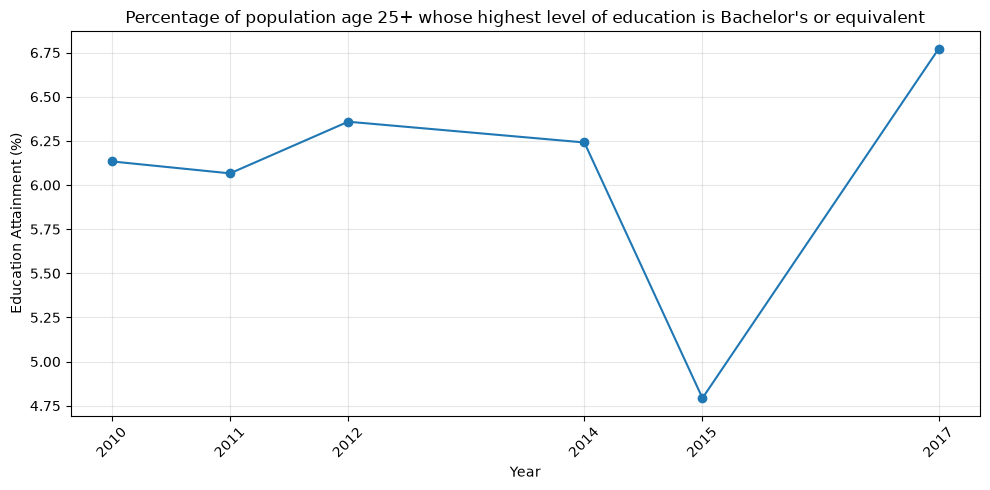

In [190]:
plt.figure(figsize=(10, 5))

plt.plot(
    analysis_df["Year"],
    analysis_df["Education_Value"],
    marker="o"
)

plt.title(
    "Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent"
)

plt.xlabel("Year")
plt.ylabel("Education Attainment (%)")

plt.xticks(
    analysis_df["Year"],
    rotation=45
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The overall pattern indicates an overall increase. The largest change occurred between 2014 and 2017, while the indicator remained relatively stable during 2010 to 2014

# LINE CHART - GDP GROWTH OVER TIME

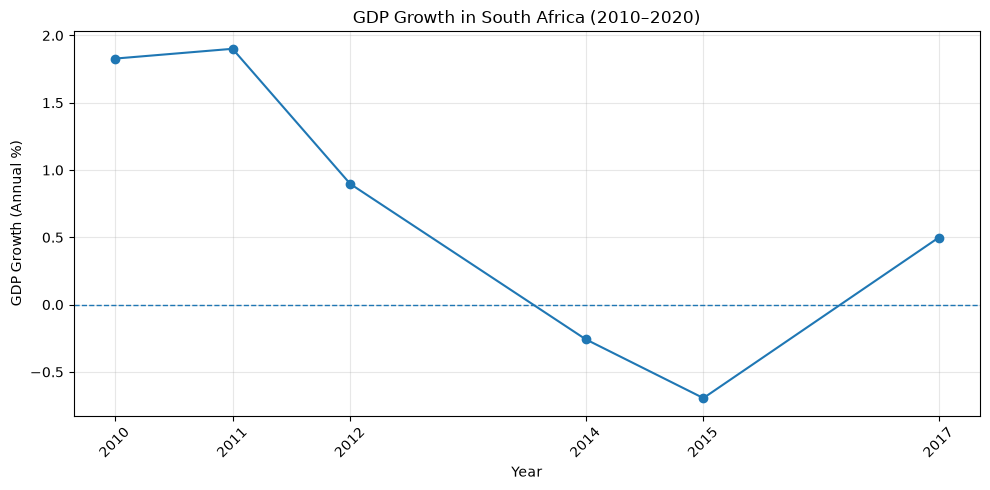

In [160]:
plt.figure(figsize=(10, 5))

plt.plot(
    analysis_df["Year"],
    analysis_df["WDI_Value"],
    marker="o"
)

plt.title(
    "GDP Growth in South Africa (2010–2020)"
)

plt.xlabel("Year")
plt.ylabel("GDP Growth (Annual %)")

plt.xticks(
    analysis_df["Year"],
    rotation=45
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The GDP growth chart shows how South Africa's economic growth changed annually between 2010 and 2020. Economic contraction is shown by negative values, and expansion is indicated by positive values. The graph allows for the comparison of shifts in educational attainment with times of higher and weaker economic performance

# SCATTER PLOT - RELATIONSHIP BETWEEN DATASETS

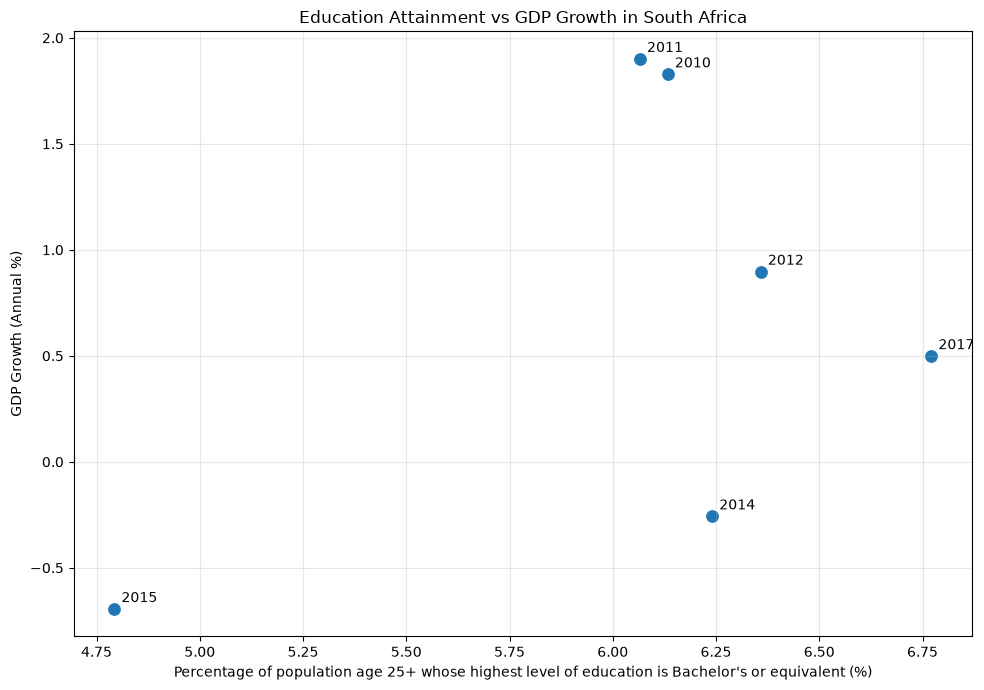

In [191]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=analysis_df,
    x="Education_Value",
    y="WDI_Value",
    s=100
)

for _, row in analysis_df.iterrows():
    plt.annotate(
        str(int(row["Year"])),
        (
            row["Education_Value"],
            row["WDI_Value"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title(
    "Education Attainment vs GDP Growth in South Africa"
)

plt.xlabel(
    "Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (%)"
)

plt.ylabel(
    "GDP Growth (Annual %)"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

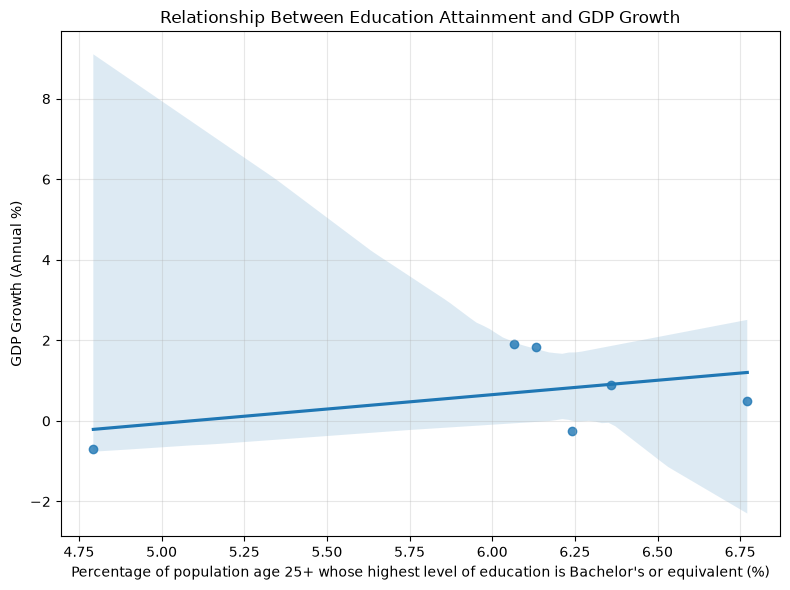

In [192]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=analysis_df,
    x="Education_Value",
    y="WDI_Value"
)

plt.title(
    "Relationship Between Education Attainment and GDP Growth"
)

plt.xlabel(
    "Percentage of population age 25+ whose highest level of education is Bachelor's or equivalent (%)"
)

plt.ylabel(
    "GDP Growth (Annual %)"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# HISTOGRAM - DISTRIBUTION DEMONSTRATION

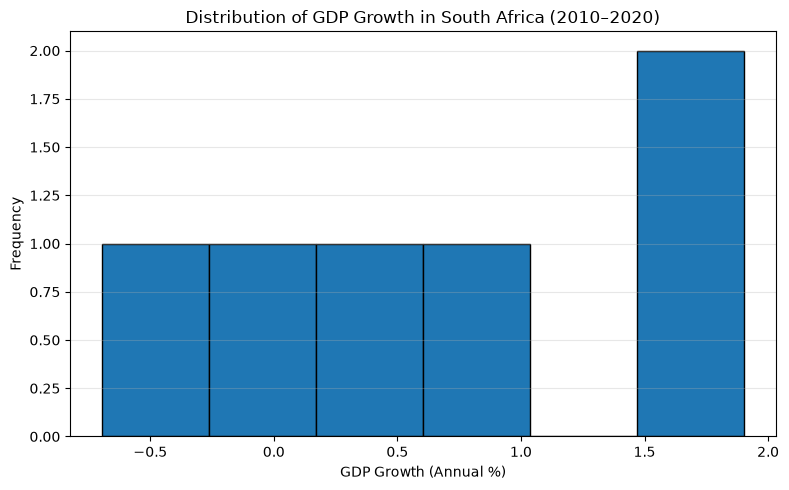

In [166]:
plt.figure(figsize=(8, 5))

plt.hist(
    analysis_df["WDI_Value"],
    bins=6,
    edgecolor="black"
)

plt.title(
    "Distribution of GDP Growth in South Africa (2010–2020)"
)

plt.xlabel("GDP Growth (Annual %)")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# BOX PLOT - GDP GROWTH

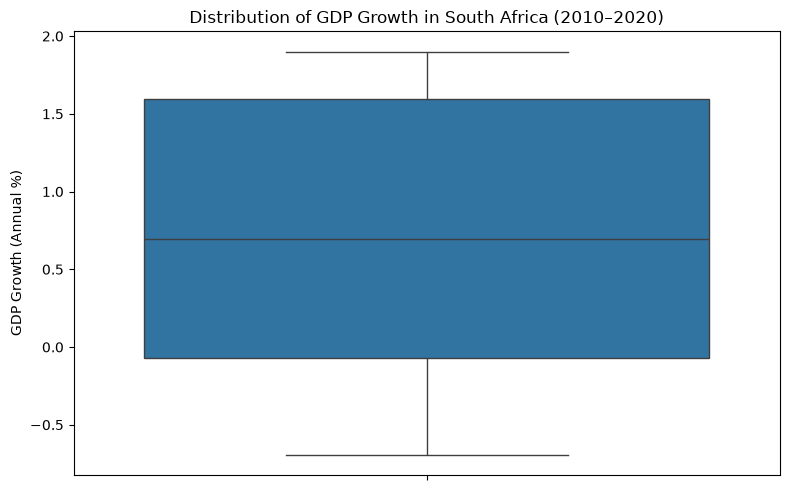

In [167]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    y=analysis_df["WDI_Value"]
)

plt.title(
    "Distribution of GDP Growth in South Africa (2010–2020)"
)

plt.ylabel("GDP Growth (Annual %)")

plt.tight_layout()
plt.show()

Depicts the median, lower and upper quartiles, spread, and potential outliers

# COMBINED TIMES-SERIES CHART

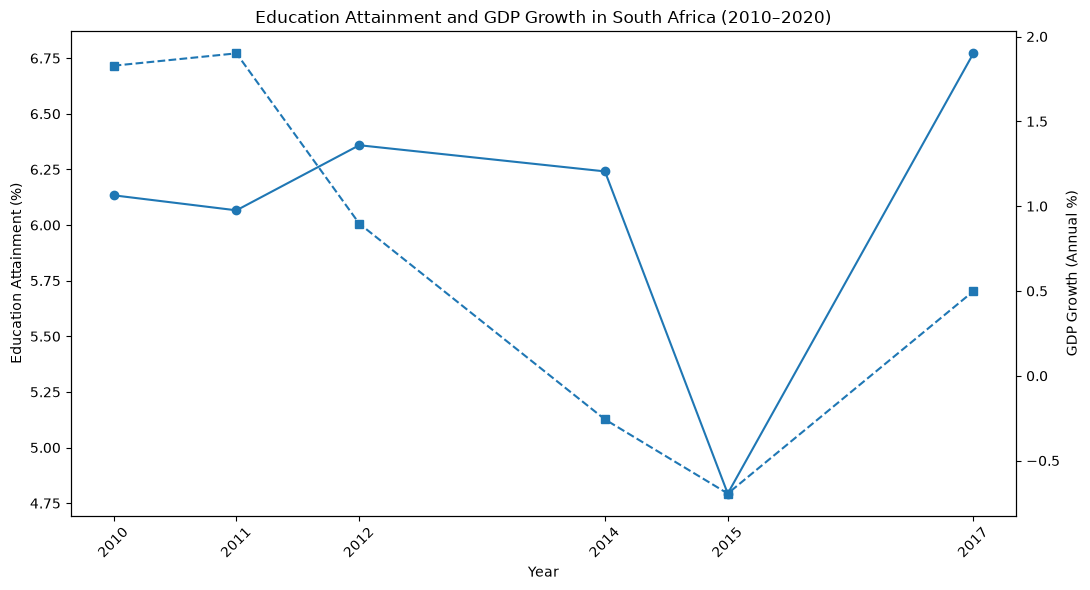

In [169]:
fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(
    analysis_df["Year"],
    analysis_df["Education_Value"],
    marker="o",
    label="Education Attainment"
)

ax1.set_xlabel("Year")
ax1.set_ylabel(
    "Education Attainment (%)"
)

ax2 = ax1.twinx()

ax2.plot(
    analysis_df["Year"],
    analysis_df["WDI_Value"],
    marker="s",
    linestyle="--",
    label="GDP Growth"
)

ax2.set_ylabel(
    "GDP Growth (Annual %)"
)

plt.title(
    "Education Attainment and GDP Growth in South Africa (2010–2020)"
)

ax1.set_xticks(analysis_df["Year"])
ax1.tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

Compares both variable over the chosen commong time (2010 - 2020)

# 4. DATABASE INTEGRATION

# DATABASE CREATION

In [170]:
import sqlite3

In [171]:
conn = sqlite3.connect("south_africa_data.db")

In [172]:
print("Database connection successful.")

Database connection successful.


# CREATING SQL TABLE

In [173]:
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS south_africa_indicators (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    year INTEGER NOT NULL,
    education_value REAL,
    wdi_value REAL
)
""")

conn.commit()

print("Table created successfully.")

Table created successfully.


In [174]:
analysis_df[
    ["Year", "Education_Value", "WDI_Value"]
].to_sql(
    "south_africa_indicators",
    conn,
    if_exists="append",
    index=False
)

6

# DATABASE QUERIES

In [175]:
query = """
SELECT *
FROM south_africa_indicators
"""

db_data = pd.read_sql_query(query, conn)

display(db_data)

,id,year,education_value,wdi_value
0,1,2010,6.13367,1.828047
1,2,2011,6.06616,1.900920
2,3,2012,6.35871,0.897180
3,4,2014,6.24111,-0.257189
4,5,2015,4.79342,-0.694265
5,6,2017,6.77162,0.498696


In [176]:
query = """
SELECT year, education_value, wdi_value
FROM south_africa_indicators
WHERE year BETWEEN 2010 AND 2020
ORDER BY year
"""

period_data = pd.read_sql_query(query, conn)

display(period_data)

,year,education_value,wdi_value
0,2010,6.13367,1.828047
1,2011,6.06616,1.900920
2,2012,6.35871,0.897180
3,2014,6.24111,-0.257189
4,2015,4.79342,-0.694265
5,2017,6.77162,0.498696


# POSITIVE GDP GROWTH - YEARS

In [177]:
query = """
SELECT year, education_value, wdi_value
FROM south_africa_indicators
WHERE wdi_value > 0
ORDER BY wdi_value DESC
"""

positive_growth = pd.read_sql_query(query, conn)

display(positive_growth)

,year,education_value,wdi_value
0,2011,6.06616,1.900920
1,2010,6.13367,1.828047
2,2012,6.35871,0.897180
3,2017,6.77162,0.498696


# NEGATIVE GDP GROWTH - YEARS

In [178]:
query = """
SELECT year, education_value, wdi_value
FROM south_africa_indicators
WHERE wdi_value < 0
ORDER BY year
"""

negative_growth = pd.read_sql_query(query, conn)

display(negative_growth)

,year,education_value,wdi_value
0,2014,6.24111,-0.257189
1,2015,4.79342,-0.694265


# HIGHEST GDP GROWTH

In [179]:
query = """
SELECT year, wdi_value
FROM south_africa_indicators
ORDER BY wdi_value DESC
LIMIT 1
"""

highest_growth = pd.read_sql_query(query, conn)

display(highest_growth)

,year,wdi_value
0,2011,1.90092


# LOWEST GDP GROWTH

In [180]:
query = """
SELECT year, wdi_value
FROM south_africa_indicators
ORDER BY wdi_value ASC
LIMIT 1
"""

lowest_growth = pd.read_sql_query(query, conn)

display(lowest_growth)

,year,wdi_value
0,2015,-0.694265


# UPDATING RECORDS

In [181]:
cursor.execute("""
UPDATE south_africa_indicators
SET education_value = ?
WHERE year = ?
""", (analysis_df.loc[
    analysis_df["Year"] == 2010,
    "Education_Value"
].iloc[0], 2010))

conn.commit()

In [182]:
query = """
SELECT *
FROM south_africa_indicators
WHERE year = 2010
"""

display(pd.read_sql_query(query, conn))

,id,year,education_value,wdi_value
0,1,2010,6.13367,1.828047


# DELETING RECORDS

Inserting a test record

In [183]:
cursor.execute("""
INSERT INTO south_africa_indicators
(year, education_value, wdi_value)
VALUES (?, ?, ?)
""", (9999, 0, 0))

conn.commit()

In [184]:
display(
    pd.read_sql_query(
        """
        SELECT *
        FROM south_africa_indicators
        WHERE year = 9999
        """,
        conn
    )
)

,id,year,education_value,wdi_value
0,7,9999,0.0,0.0


Deleting it

In [185]:
cursor.execute("""
DELETE FROM south_africa_indicators
WHERE year = ?
""", (9999,))

conn.commit()

In [186]:
display(
    pd.read_sql_query(
        """
        SELECT *
        FROM south_africa_indicators
        WHERE year = 9999
        """,
        conn
    )
)

,id,year,education_value,wdi_value


# LOADING DATABASE INTO PANDAS

In [187]:
query = """
SELECT year, education_value, wdi_value
FROM south_africa_indicators
ORDER BY year
"""

analysis_from_db = pd.read_sql_query(
    query,
    conn
)

display(analysis_from_db)

,year,education_value,wdi_value
0,2010,6.13367,1.828047
1,2011,6.06616,1.900920
2,2012,6.35871,0.897180
3,2014,6.24111,-0.257189
4,2015,4.79342,-0.694265
5,2017,6.77162,0.498696


In [189]:
analysis_from_db.to_csv(
    "south_africa_indicators_from_database.csv",
    index=False
)

print("Database data exported successfully.")

Database data exported successfully.


# 5. PYTHON DATA ANALYSIS

In [193]:
display(analysis_df.head())

,Year,Education_Value,WDI_Value
0,2010,6.13367,1.828047
1,2011,6.06616,1.900920
2,2012,6.35871,0.897180
3,2014,6.24111,-0.257189
4,2015,4.79342,-0.694265


# DATA CLEANING

In [197]:
analysis_clean = analysis_df.dropna(
    subset=["Education_Value", "WDI_Value"]
).copy()

In [198]:
print("Rows before cleaning:", len(analysis_df))
print("Rows after cleaning:", len(analysis_clean))

Rows before cleaning: 6
Rows after cleaning: 6


In [199]:
display(analysis_clean)

,Year,Education_Value,WDI_Value
0,2010,6.13367,1.828047
1,2011,6.06616,1.900920
2,2012,6.35871,0.897180
3,2014,6.24111,-0.257189
4,2015,4.79342,-0.694265
5,2017,6.77162,0.498696


# DATA TRANSFORMATION

In [200]:
analysis_clean["Education_Change"] = (
    analysis_clean["Education_Value"].diff()
)

In [201]:
display(
    analysis_clean[
        ["Year", "Education_Value", "Education_Change"]
    ]
)

,Year,Education_Value,Education_Change
0,2010,6.13367,NaN
1,2011,6.06616,-0.06751
2,2012,6.35871,0.29255
3,2014,6.24111,-0.11760
4,2015,4.79342,-1.44769
5,2017,6.77162,1.97820


Year-to-year change in education attainment calculation

# TRANSFORMING GDP GROWTH INTO CATEGORIES

In [202]:
analysis_clean["GDP_Growth_Category"] = pd.cut(
    analysis_clean["WDI_Value"],
    bins=[-float("inf"), 0, 3, float("inf")],
    labels=[
        "Negative Growth",
        "Low/Moderate Growth",
        "High Growth"
    ]
)

In [203]:
display(
    analysis_clean[
        ["Year", "WDI_Value", "GDP_Growth_Category"]
    ]
)

,Year,WDI_Value,GDP_Growth_Category
0,2010,1.828047,Low/Moderate Growth
1,2011,1.900920,Low/Moderate Growth
2,2012,0.897180,Low/Moderate Growth
3,2014,-0.257189,Negative Growth
4,2015,-0.694265,Negative Growth
5,2017,0.498696,Low/Moderate Growth


The table has been conditionally formatted

# SUMMARY TABLE

In [210]:
summary_table = analysis_clean[
    [
        "Year",
        "Education_Value",
        "WDI_Value",
        "Education_Change",
        "GDP_Growth_Category"
    ]
]

display(summary_table)

,Year,Education_Value,WDI_Value,Education_Change,GDP_Growth_Category
0,2010,6.13367,1.828047,NaN,Low/Moderate Growth
1,2011,6.06616,1.900920,-0.06751,Low/Moderate Growth
2,2012,6.35871,0.897180,0.29255,Low/Moderate Growth
3,2014,6.24111,-0.257189,-0.11760,Negative Growth
4,2015,4.79342,-0.694265,-1.44769,Negative Growth
5,2017,6.77162,0.498696,1.97820,Low/Moderate Growth


# APPLYING CONDITIONAL FORMATTING TO GDP GROWTH

In [211]:
styled_table = analysis_clean[
    [
        "Year",
        "Education_Value",
        "WDI_Value",
        "Education_Change"
    ]
].style.background_gradient(
    subset=["WDI_Value"],
    cmap="RdYlGn"
)

styled_table

,Year,Education_Value,WDI_Value,Education_Change
0,2010,6.133670,1.828047,nan
1,2011,6.066160,1.900920,-0.067510
2,2012,6.358710,0.897180,0.292550
3,2014,6.241110,-0.257189,-0.117600
4,2015,4.793420,-0.694265,-1.447690
5,2017,6.771620,0.498696,1.978200


# APPLYING CONDITIONAL FORMATTING TO EDUCATION ATTAINMENT

In [212]:
education_style = analysis_clean[
    [
        "Year",
        "Education_Value",
        "WDI_Value"
    ]
].style.background_gradient(
    subset=["Education_Value"],
    cmap="Blues"
)

education_style

,Year,Education_Value,WDI_Value
0,2010,6.133670,1.828047
1,2011,6.066160,1.900920
2,2012,6.358710,0.897180
3,2014,6.241110,-0.257189
4,2015,4.793420,-0.694265
5,2017,6.771620,0.498696


# END